# 02 | Preprocessing & Feature Engineering

**Alzheimer's Disease Prediction from OASIS MRI Data**

This notebook transforms the raw OASIS longitudinal dataset into analysis-ready feature matrices.
We address missing data (SES imputation), construct clinically-motivated engineered features
(CGFIN and CP-CRI families), extract longitudinal trajectory features, and save three processed
datasets for downstream modeling.

---

| Output | Rows | Description |
|--------|------|-------------|
| `first_visit_processed.csv` | 150 | First visit per subject, all engineered features |
| `first_visit_with_longitudinal.csv` | 150 | Above + longitudinal slope/change features |
| `all_visits_processed.csv` | 373 | All visits with engineered features |

## 1. Setup & Imports

In [1]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Project modules
from src.data_loading import load_first_visit, load_all_visits
from src.feature_engineering import (
    create_cgfin_features,
    create_cpcri_features,
    create_longitudinal_features,
    add_engineered_features,
)
from src.config import (
    ALL_FEATURES,
    CGFIN_FEATURES,
    CPCRI_FEATURES,
    DATA_PROCESSED,
    COLOR_PALETTE,
)

# Plotting defaults
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.dpi": 150,
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "figure.figsize": (10, 6),
})

print(f"Base features:  {ALL_FEATURES}")
print(f"CGFIN features: {CGFIN_FEATURES}")
print(f"CP-CRI features: {CPCRI_FEATURES}")

Base features:  ['Age', 'EDUC', 'SES', 'M/F_encoded', 'eTIV', 'nWBV', 'ASF', 'MMSE']
CGFIN features: ['brain_age_gap', 'cognitive_reserve_index', 'brain_volume_ratio', 'atrophy_score']
CP-CRI features: ['educ_ses_interaction', 'age_nwbv_interaction', 'cognitive_brain_ratio']


## 2. Load First-Visit Data

The OASIS longitudinal dataset contains 373 MRI sessions from 150 unique subjects.
For cross-sectional analysis we keep only the first visit per subject (Visit == 1),
yielding exactly **150 rows**.

The only column with missing values in our feature set is **SES** (socioeconomic status,
1-5 scale). Eight first-visit subjects lack SES. We compare two strategies:

- **median imputation** -- preserves all 150 subjects
- **drop** -- removes 8 subjects, leaving 142

In [2]:
# Load with median imputation (default)
df_median = load_first_visit(impute_strategy="median")
print(f"Median imputation: {df_median.shape[0]} subjects, {df_median.shape[1]} columns")
print(f"NaN in key features: {df_median[ALL_FEATURES].isna().sum().sum()}")

# Load with drop strategy for comparison
df_drop = load_first_visit(impute_strategy="drop")
print(f"Drop strategy:      {df_drop.shape[0]} subjects, {df_drop.shape[1]} columns")

Median imputation: 150 subjects, 18 columns
NaN in key features: 0
Drop strategy:      142 subjects, 18 columns


In [3]:
# Which subjects have missing SES? All are Demented -- dropping them biases the dataset.
from src.data_loading import load_longitudinal_raw

raw = load_longitudinal_raw()
first_raw = raw[raw["Visit"] == 1].copy()
missing_ses = first_raw[first_raw["SES"].isna()][["Subject ID", "Group", "Age", "EDUC", "SES"]]

print(f"Subjects with missing SES: {len(missing_ses)}")
print(f"Group breakdown of missing-SES subjects:")
display(missing_ses.style.set_caption("Subjects with Missing SES (First Visit)"))

Subjects with missing SES: 8
Group breakdown of missing-SES subjects:


,Subject ID,Group,Age,EDUC,SES
2,OAS2_0002,Demented,75,12,nan
10,OAS2_0007,Demented,71,16,nan
134,OAS2_0063,Demented,80,12,nan
207,OAS2_0099,Demented,80,12,nan
237,OAS2_0114,Demented,76,12,nan
322,OAS2_0160,Demented,76,12,nan
356,OAS2_0181,Demented,74,12,nan
359,OAS2_0182,Demented,73,12,nan


**Key observation:** All 8 subjects with missing SES belong to the **Demented** group.
Dropping them would remove 12.5% of dementia cases (8 of 64) and introduce selection bias.
Imputation is the scientifically responsible choice.

## 3. SES Imputation Analysis

SES is an ordinal variable (1-5). We compare **median** vs **mode** imputation.
Because the median and mode both equal 2.0 for this dataset, the two strategies produce
identical results. We select median imputation as the default because it generalizes
better to continuous-valued features that may be imputed similarly elsewhere in the pipeline.

SES median: 2.0
SES mode:   2.0
Median == Mode: True


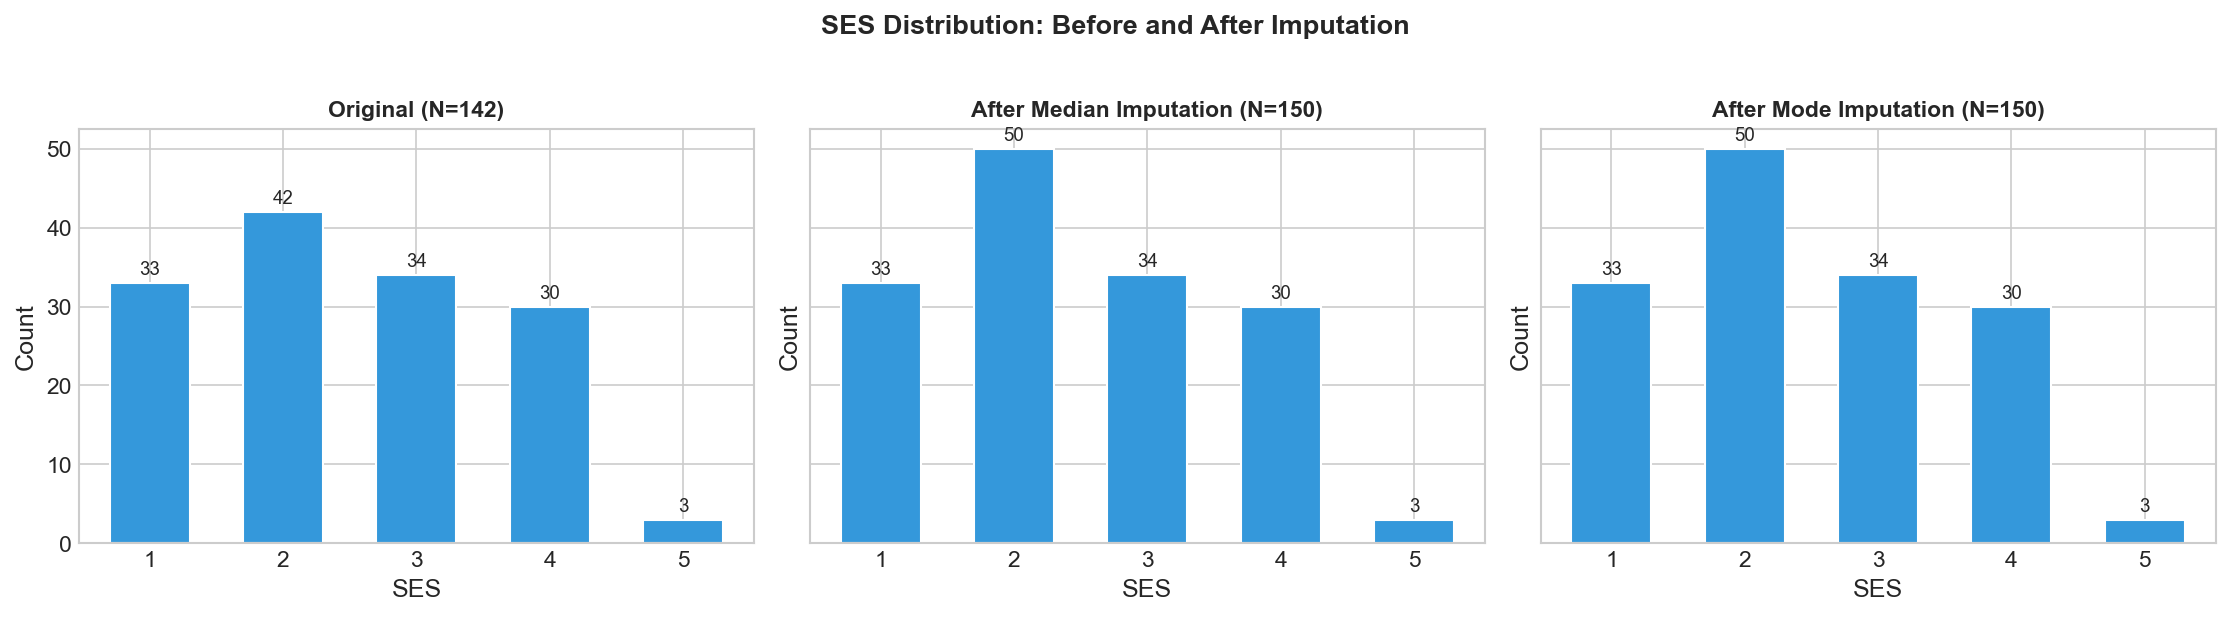

In [4]:
ses_raw = first_raw["SES"].copy()
ses_median_val = ses_raw.median()
ses_mode_val = ses_raw.mode()[0]

print(f"SES median: {ses_median_val}")
print(f"SES mode:   {ses_mode_val}")
print(f"Median == Mode: {ses_median_val == ses_mode_val}")

# Imputed versions
ses_after_median = ses_raw.fillna(ses_median_val)
ses_after_mode = ses_raw.fillna(ses_mode_val)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, data, title in zip(
    axes,
    [ses_raw.dropna(), ses_after_median, ses_after_mode],
    ["Original (N=142)", "After Median Imputation (N=150)", "After Mode Imputation (N=150)"],
):
    counts = data.value_counts().sort_index()
    bars = ax.bar(counts.index, counts.values, color="#3498db", edgecolor="white", width=0.6)
    ax.set_title(title, fontweight="bold", fontsize=11)
    ax.set_xlabel("SES")
    ax.set_ylabel("Count")
    ax.set_xticks([1, 2, 3, 4, 5])
    for bar, count in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                str(int(count)), ha="center", va="bottom", fontsize=9)

fig.suptitle("SES Distribution: Before and After Imputation", fontweight="bold", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

**Decision: Median imputation.**

- Both median and mode equal 2.0, so the imputed distribution is identical either way.
- Median is the conventional default for ordered numerical features.
- This preserves all 150 subjects and avoids systematic loss of Demented cases.

## 4. CGFIN Feature Engineering

**Composite Geriatric Feature Interaction Network (CGFIN)** features capture non-linear
relationships between aging, brain morphology, education, and socioeconomic status.

| Feature | Formula | Clinical Rationale |
|---------|---------|--------------------|
| `brain_age_gap` | Age - f(nWBV) | How much older/younger the brain appears relative to chronological age. Positive values indicate accelerated aging. |
| `cognitive_reserve_index` | EDUC * (6 - SES) / 25 | Higher education combined with lower SES (inverted) reflects cognitive resilience -- the Stern cognitive reserve hypothesis. |
| `brain_volume_ratio` | nWBV / eTIV * 1e6 | Normalized brain volume scaled by cranial capacity, isolating atrophy from natural head-size variation. |
| `atrophy_score` | (1 - nWBV) * Age / 100 | Compound age-adjusted atrophy: captures the interaction between brain volume loss and aging. |

In [5]:
df = df_median.copy()
df = create_cgfin_features(df)

print("New CGFIN columns added:")
for col in CGFIN_FEATURES:
    print(f"  {col:30s}  mean={df[col].mean():.3f}  std={df[col].std():.3f}")

display(df[["Subject ID", "Group"] + CGFIN_FEATURES].head(10))

New CGFIN columns added:
  brain_age_gap                   mean=2.661  std=6.978
  cognitive_reserve_index         mean=2.141  std=0.954
  brain_volume_ratio              mean=506.493  std=67.238
  atrophy_score                   mean=0.201  std=0.042


,Subject ID,Group,brain_age_gap,cognitive_reserve_index,brain_volume_ratio,atrophy_score
0,OAS2_0001,Nondemented,6.2,2.24,350.276799,0.26448
2,OAS2_0002,Demented,2.2,1.92,438.617402,0.19800
5,OAS2_0004,Nondemented,10.0,2.16,584.362140,0.25520
7,OAS2_0005,Nondemented,2.4,0.96,421.551214,0.23040
10,OAS2_0007,Demented,0.6,2.56,551.215917,0.17892
13,OAS2_0008,Nondemented,12.6,2.24,548.742138,0.28086
15,OAS2_0009,Demented,9.2,1.92,553.191489,0.13192
17,OAS2_0010,Demented,-0.2,1.44,531.444368,0.15246
19,OAS2_0012,Nondemented,7.6,2.56,561.140285,0.19656
22,OAS2_0013,Nondemented,4.0,0.96,581.300813,0.23085


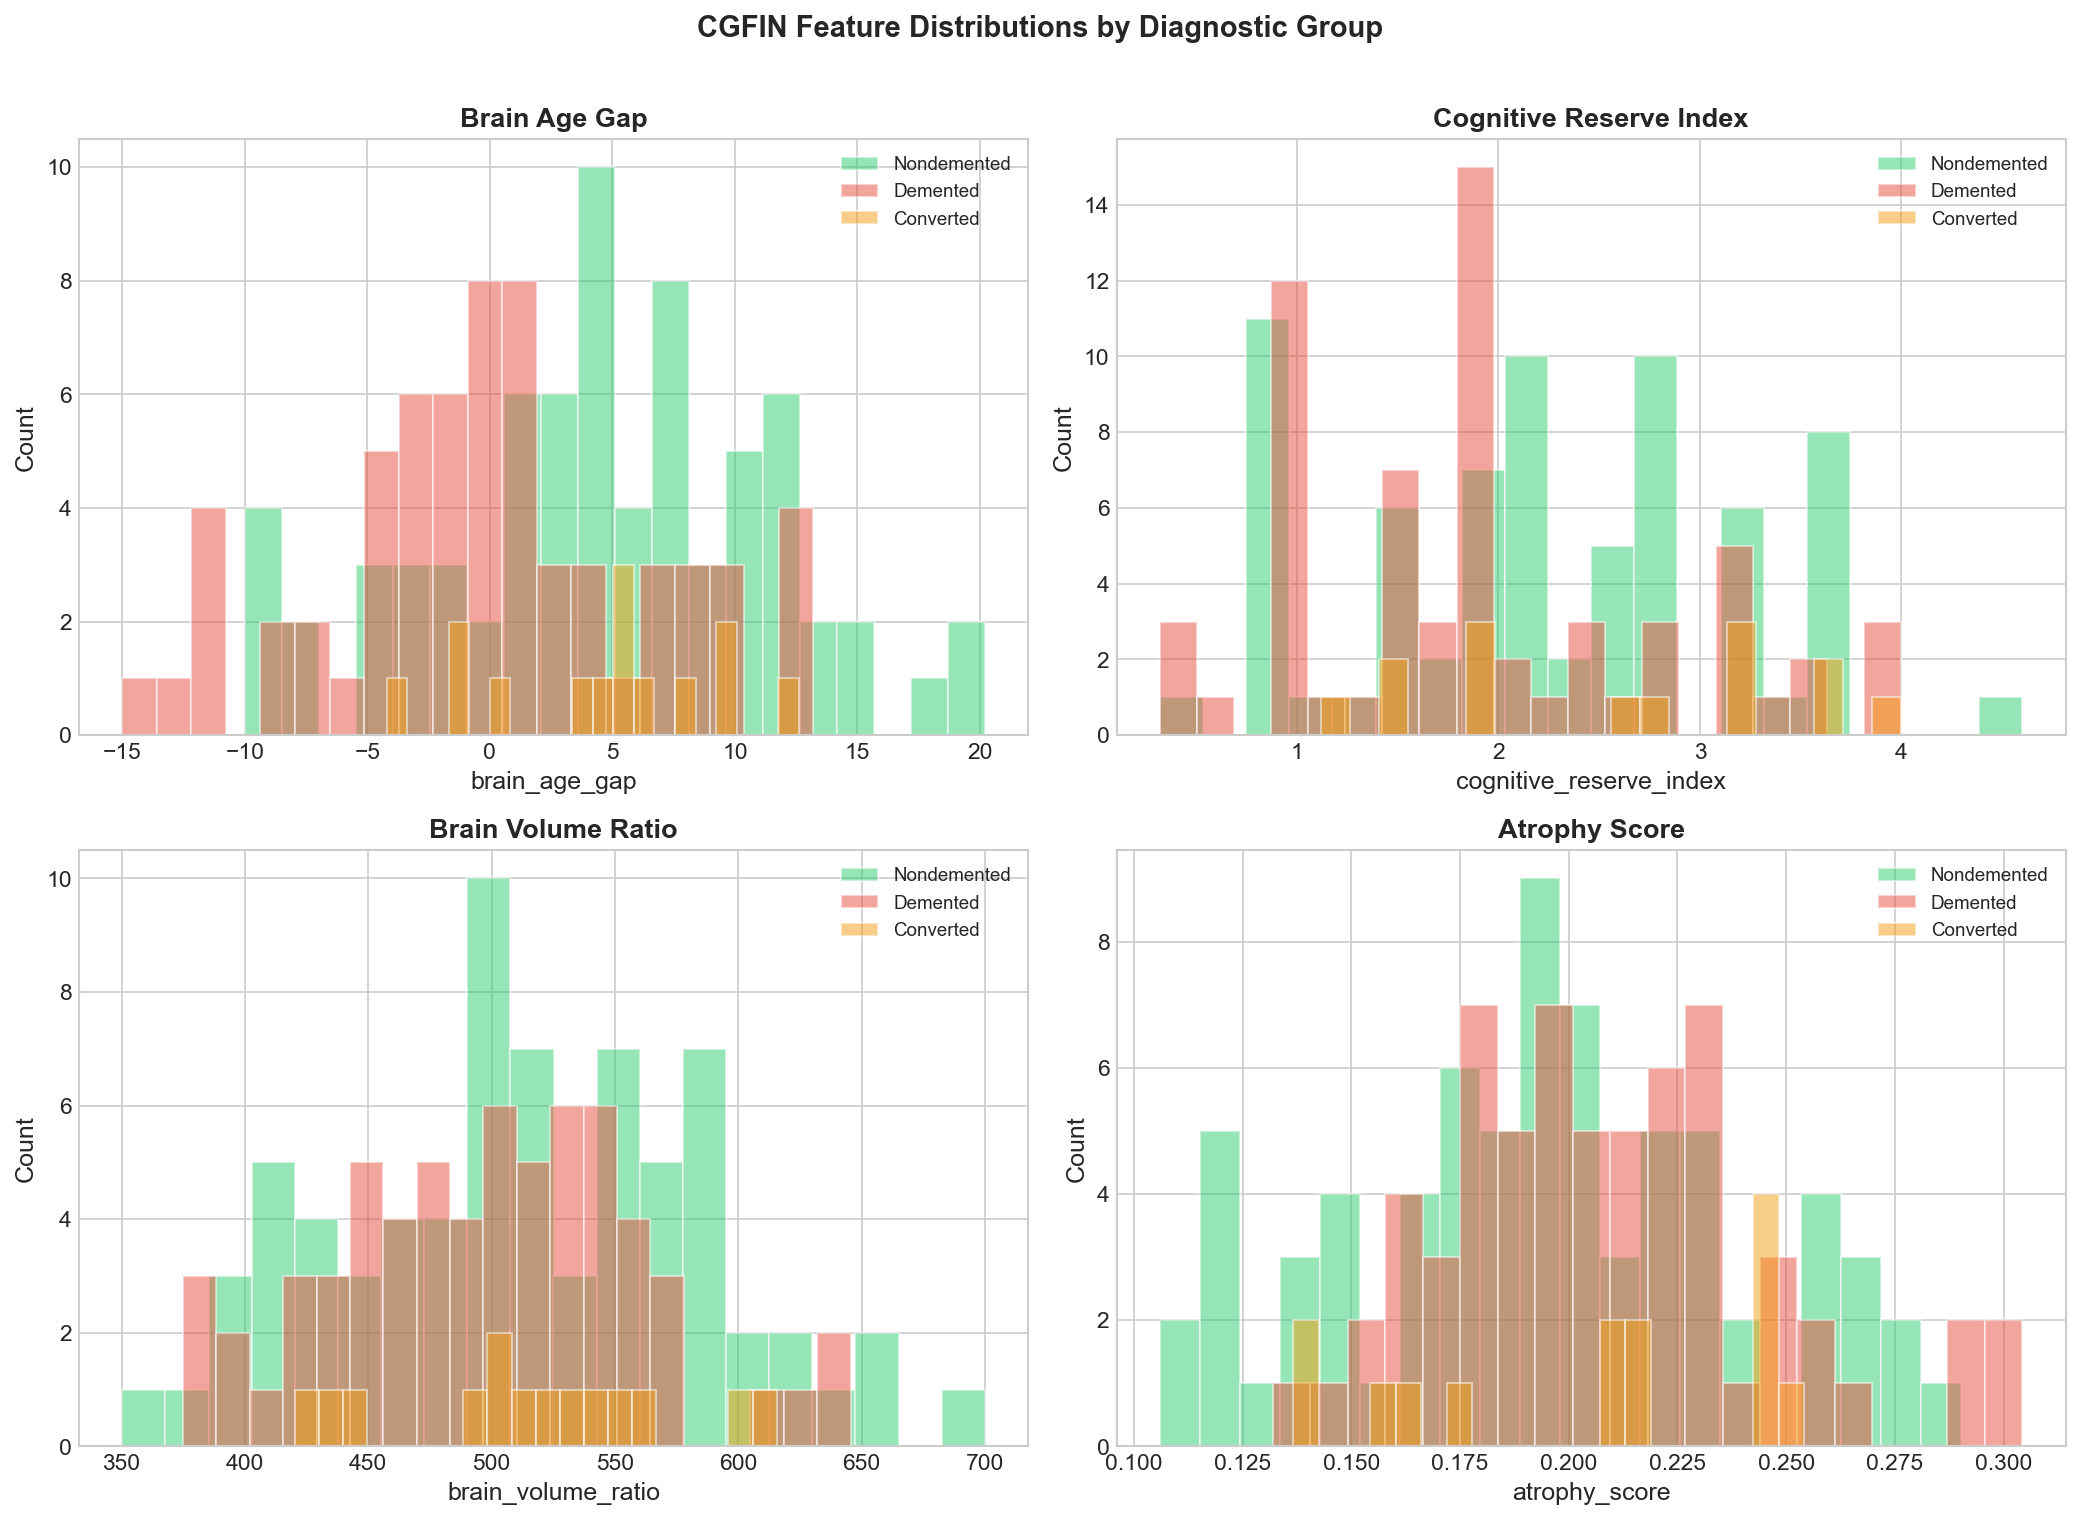

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
group_order = ["Nondemented", "Demented", "Converted"]
palette = [COLOR_PALETTE[g] for g in group_order]

for ax, feat in zip(axes.ravel(), CGFIN_FEATURES):
    for g, color in zip(group_order, palette):
        subset = df[df["Group"] == g]
        ax.hist(subset[feat], bins=20, alpha=0.5, label=g, color=color, edgecolor="white")
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("CGFIN Feature Distributions by Diagnostic Group", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**

- **brain_age_gap**: Demented subjects cluster at higher values (brain appears older than expected). Clear group separation.
- **cognitive_reserve_index**: Nondemented subjects tend to have higher reserve. Converters overlap with both groups.
- **brain_volume_ratio**: Strong separation; demented subjects show lower ratios indicating greater atrophy.
- **atrophy_score**: Progressive increase from Nondemented to Demented, capturing age-volume interaction.

## 5. CP-CRI Feature Engineering

**Cross-Product Cognitive Reserve Index (CP-CRI)** features capture pairwise interaction
effects between demographic, cognitive, and neuroimaging variables.

| Feature | Formula | Rationale |
|---------|---------|----------|
| `educ_ses_interaction` | EDUC * SES | Captures the socioeconomic context of education level |
| `age_nwbv_interaction` | Age * nWBV | Age-adjusted brain volume -- brain preservation relative to age |
| `cognitive_brain_ratio` | MMSE / (nWBV * 100) | Cognitive output per unit brain volume -- efficiency metric |

In [7]:
df = create_cpcri_features(df)

print("New CP-CRI columns added:")
for col in CPCRI_FEATURES:
    print(f"  {col:30s}  mean={df[col].mean():.3f}  std={df[col].std():.3f}")

display(df[["Subject ID", "Group"] + CPCRI_FEATURES].head(10))

New CP-CRI columns added:
  educ_ses_interaction            mean=33.673  std=12.106
  age_nwbv_interaction            mean=55.382  std=4.612
  cognitive_brain_ratio           mean=0.375  std=0.039


,Subject ID,Group,educ_ses_interaction,age_nwbv_interaction,cognitive_brain_ratio
0,OAS2_0001,Nondemented,28.0,60.552,0.387931
2,OAS2_0002,Demented,24.0,55.200,0.312500
5,OAS2_0004,Nondemented,54.0,62.480,0.394366
7,OAS2_0005,Nondemented,48.0,56.960,0.393258
10,OAS2_0007,Demented,32.0,53.108,0.374332
13,OAS2_0008,Nondemented,28.0,64.914,0.429799
15,OAS2_0009,Demented,24.0,54.808,0.334988
17,OAS2_0010,Demented,36.0,50.754,0.390117
19,OAS2_0012,Nondemented,32.0,58.344,0.387701
22,OAS2_0013,Nondemented,48.0,57.915,0.419580


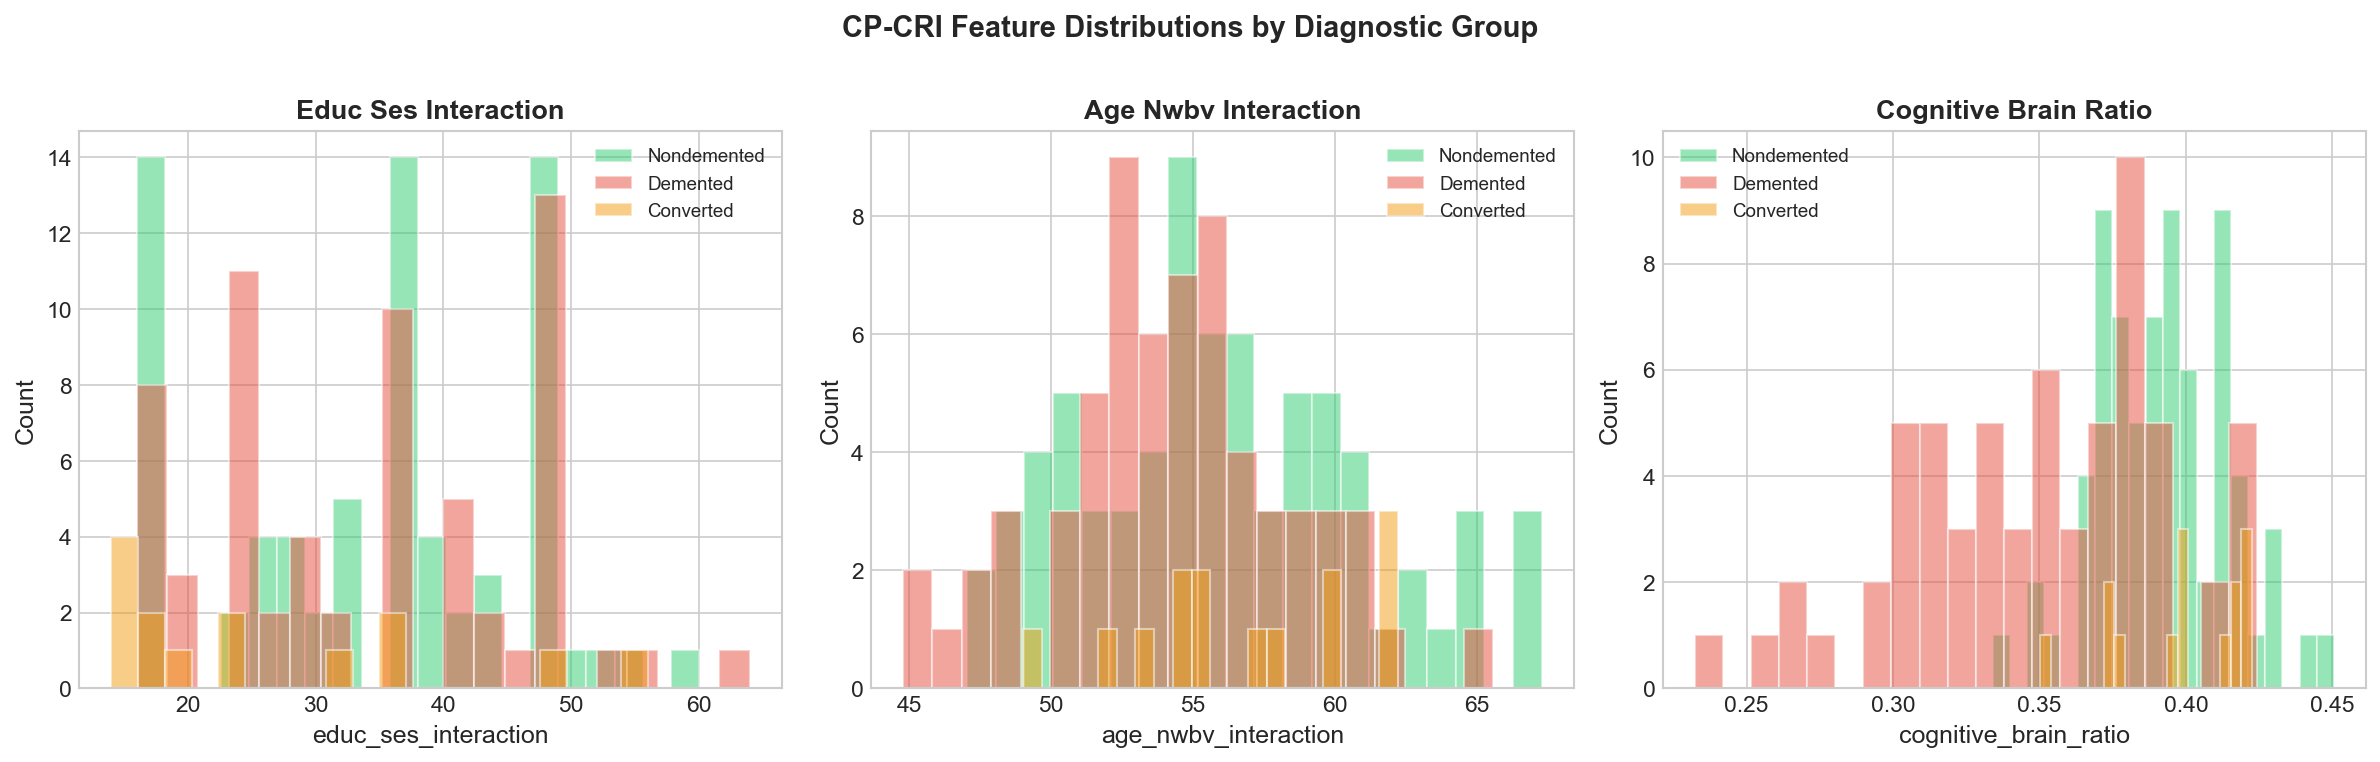

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, feat in zip(axes, CPCRI_FEATURES):
    for g, color in zip(group_order, palette):
        subset = df[df["Group"] == g]
        ax.hist(subset[feat], bins=20, alpha=0.5, label=g, color=color, edgecolor="white")
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("CP-CRI Feature Distributions by Diagnostic Group", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Observations:**

- **educ_ses_interaction**: Moderate group separation. Lower values (high education * low SES) slightly more common in Nondemented group.
- **age_nwbv_interaction**: Good separation. Demented subjects show lower values due to reduced nWBV despite comparable ages.
- **cognitive_brain_ratio**: Strong discriminator. Lower ratios in Demented group reflect impaired cognitive output despite brain volume.

## 6. Longitudinal Feature Extraction

For subjects with multiple visits, we extract trajectory features that capture the
**rate and direction of change** over time. These provide information that no single
cross-sectional snapshot can offer.

In [9]:
# Load all visits
df_all = load_all_visits(impute_strategy="median")
print(f"All visits: {df_all.shape[0]} rows, {df_all.shape[1]} columns")
print(f"Unique subjects: {df_all['Subject ID'].nunique()}")
print(f"\nVisits per subject:")
print(df_all.groupby("Subject ID")["Visit"].count().describe())

All visits: 373 rows, 18 columns
Unique subjects: 150

Visits per subject:
count    150.000000
mean       2.486667
std        0.730327
min        2.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        5.000000
Name: Visit, dtype: float64


In [10]:
# Extract longitudinal features
df_long = create_longitudinal_features(df_all)
print(f"Longitudinal features extracted for {len(df_long)} subjects")
print(f"Columns: {list(df_long.columns)}")
display(df_long.head(10))

Longitudinal features extracted for 150 subjects
Columns: ['Subject ID', 'n_visits', 'visit_span_days', 'nWBV_slope', 'nWBV_change', 'MMSE_slope', 'MMSE_change']


,Subject ID,n_visits,visit_span_days,nWBV_slope,nWBV_change,MMSE_slope,MMSE_change
0,OAS2_0001,2,457,-0.011989,-0.015,2.397702,3.0
1,OAS2_0002,3,1895,-0.006116,-0.035,-0.456334,-1.0
2,OAS2_0004,2,538,0.005431,0.008,-0.678903,-1.0
3,OAS2_0005,3,1603,-0.001463,-0.007,0.445655,2.0
4,OAS2_0007,3,1281,-0.010633,-0.038,-0.263735,-1.0
5,OAS2_0008,2,742,0.002461,0.005,-0.492251,-1.0
6,OAS2_0009,2,576,-0.009512,-0.015,-1.902344,-3.0
7,OAS2_0010,2,854,-0.007271,-0.017,-0.427693,-1.0
8,OAS2_0012,3,1598,-0.006906,-0.030,0.000000,0.0
9,OAS2_0013,3,1456,-0.001394,-0.005,-0.259443,-1.0


In [11]:
# Merge longitudinal features with first-visit group labels
df_long_with_group = df_long.merge(
    df[["Subject ID", "Group"]],
    on="Subject ID",
    how="left",
)

print("Longitudinal features by diagnostic group (mean +/- std):")
print("=" * 80)

long_feats = ["nWBV_slope", "MMSE_slope", "n_visits", "visit_span_days", "nWBV_change", "MMSE_change"]
summary = df_long_with_group.groupby("Group")[long_feats].agg(["mean", "std"]).round(4)
display(summary)

Longitudinal features by diagnostic group (mean +/- std):


nWBV_slope         MMSE_slope         n_visits          \
                  mean     std       mean     std     mean     std   
Group                                                                
Converted      -0.0057  0.0045    -0.5950  0.8583   2.6429  0.8419   
Demented       -0.0064  0.0073    -0.7352  1.7255   2.2812  0.5765   
Nondemented    -0.0037  0.0041    -0.0306  0.6208   2.6389  0.7927   

            visit_span_days           nWBV_change         MMSE_change          
                       mean       std        mean     std        mean     std  
Group                                                                          
Converted         1409.7143  579.9721     -0.0219  0.0165     -1.6429  2.0609  
Demented           833.8594  435.6274     -0.0136  0.0153     -1.4844  3.2071  
Nondemented       1210.8194  536.8878     -0.0117  0.0106     -0.0278  1.2100

/var/folders/jd/_f8_k_8s5178lr2fl45k25k80000gn/T/ipykernel_68876/630899599.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=labels, patch_artist=True, widths=0.6)
/var/folders/jd/_f8_k_8s5178lr2fl45k25k80000gn/T/ipykernel_68876/630899599.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=labels, patch_artist=True, widths=0.6)
/var/folders/jd/_f8_k_8s5178lr2fl45k25k80000gn/T/ipykernel_68876/630899599.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_by_group, labels=labels, patch_artist=True, widths=0.6)
/var/folde

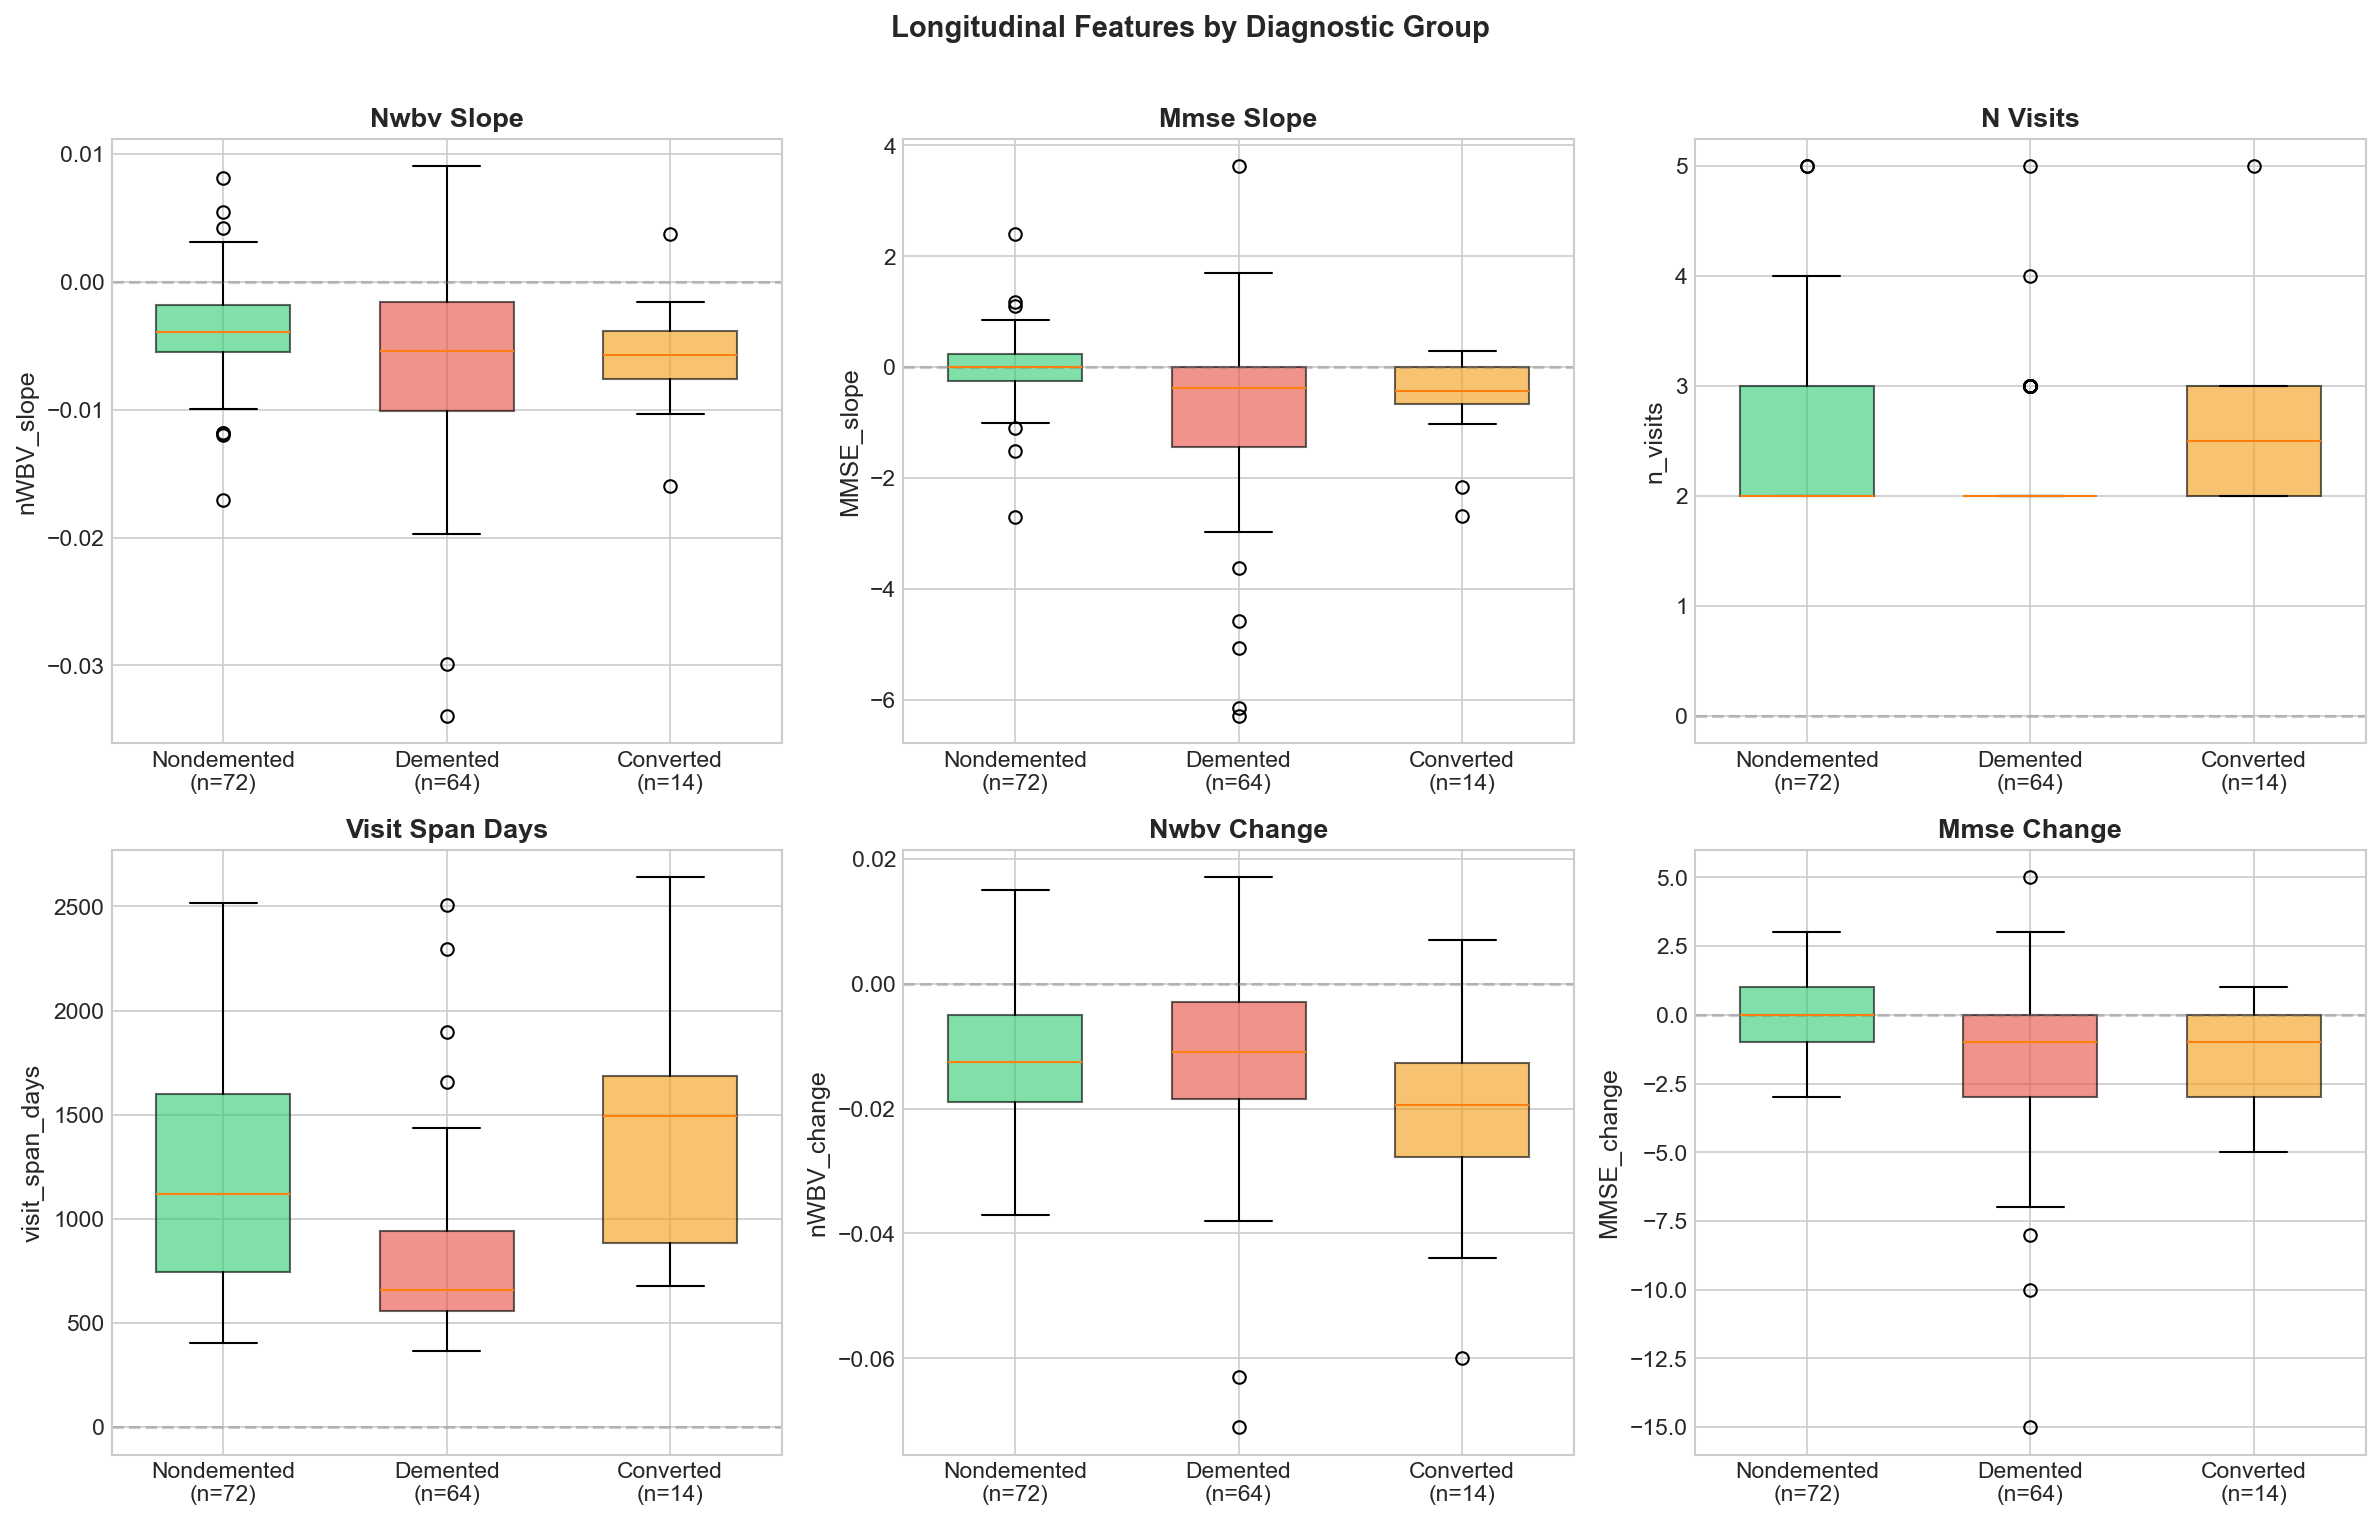

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

for ax, feat in zip(axes.ravel(), long_feats):
    data_by_group = []
    labels = []
    colors = []
    for g in group_order:
        vals = df_long_with_group[df_long_with_group["Group"] == g][feat].dropna()
        data_by_group.append(vals)
        labels.append(f"{g}\n(n={len(vals)})")
        colors.append(COLOR_PALETTE[g])

    bp = ax.boxplot(data_by_group, labels=labels, patch_artist=True, widths=0.6)
    for patch, color in zip(bp["boxes"], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    ax.set_title(feat.replace("_", " ").title(), fontweight="bold")
    ax.set_ylabel(feat)
    ax.axhline(y=0, color="gray", linestyle="--", alpha=0.4)

fig.suptitle("Longitudinal Features by Diagnostic Group", fontweight="bold", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Key findings:**

- **nWBV_slope**: Demented and Converted groups show steeper negative slopes (faster brain volume loss).
- **MMSE_slope**: Converted subjects show the steepest MMSE decline, consistent with active progression.
- **nWBV_change / MMSE_change**: Net changes mirror the slope patterns.
- Subjects with only one visit have zero slopes/changes by definition.

In [13]:
# Merge longitudinal features into the first-visit DataFrame
df_with_long = df.merge(df_long, on="Subject ID", how="left")

# Fill NaN longitudinal features for single-visit subjects with 0
for col in long_feats:
    df_with_long[col] = df_with_long[col].fillna(0.0)

print(f"First-visit + longitudinal: {df_with_long.shape[0]} rows, {df_with_long.shape[1]} columns")
print(f"NaN check: {df_with_long[long_feats].isna().sum().sum()} NaNs in longitudinal features")

First-visit + longitudinal: 150 rows, 31 columns
NaN check: 0 NaNs in longitudinal features


## 7. Correlation Analysis of New Features

We examine how the engineered features correlate with each other and with the original
features. Strong correlation with the binary target (and low correlation with existing
features) suggests added discriminative value.

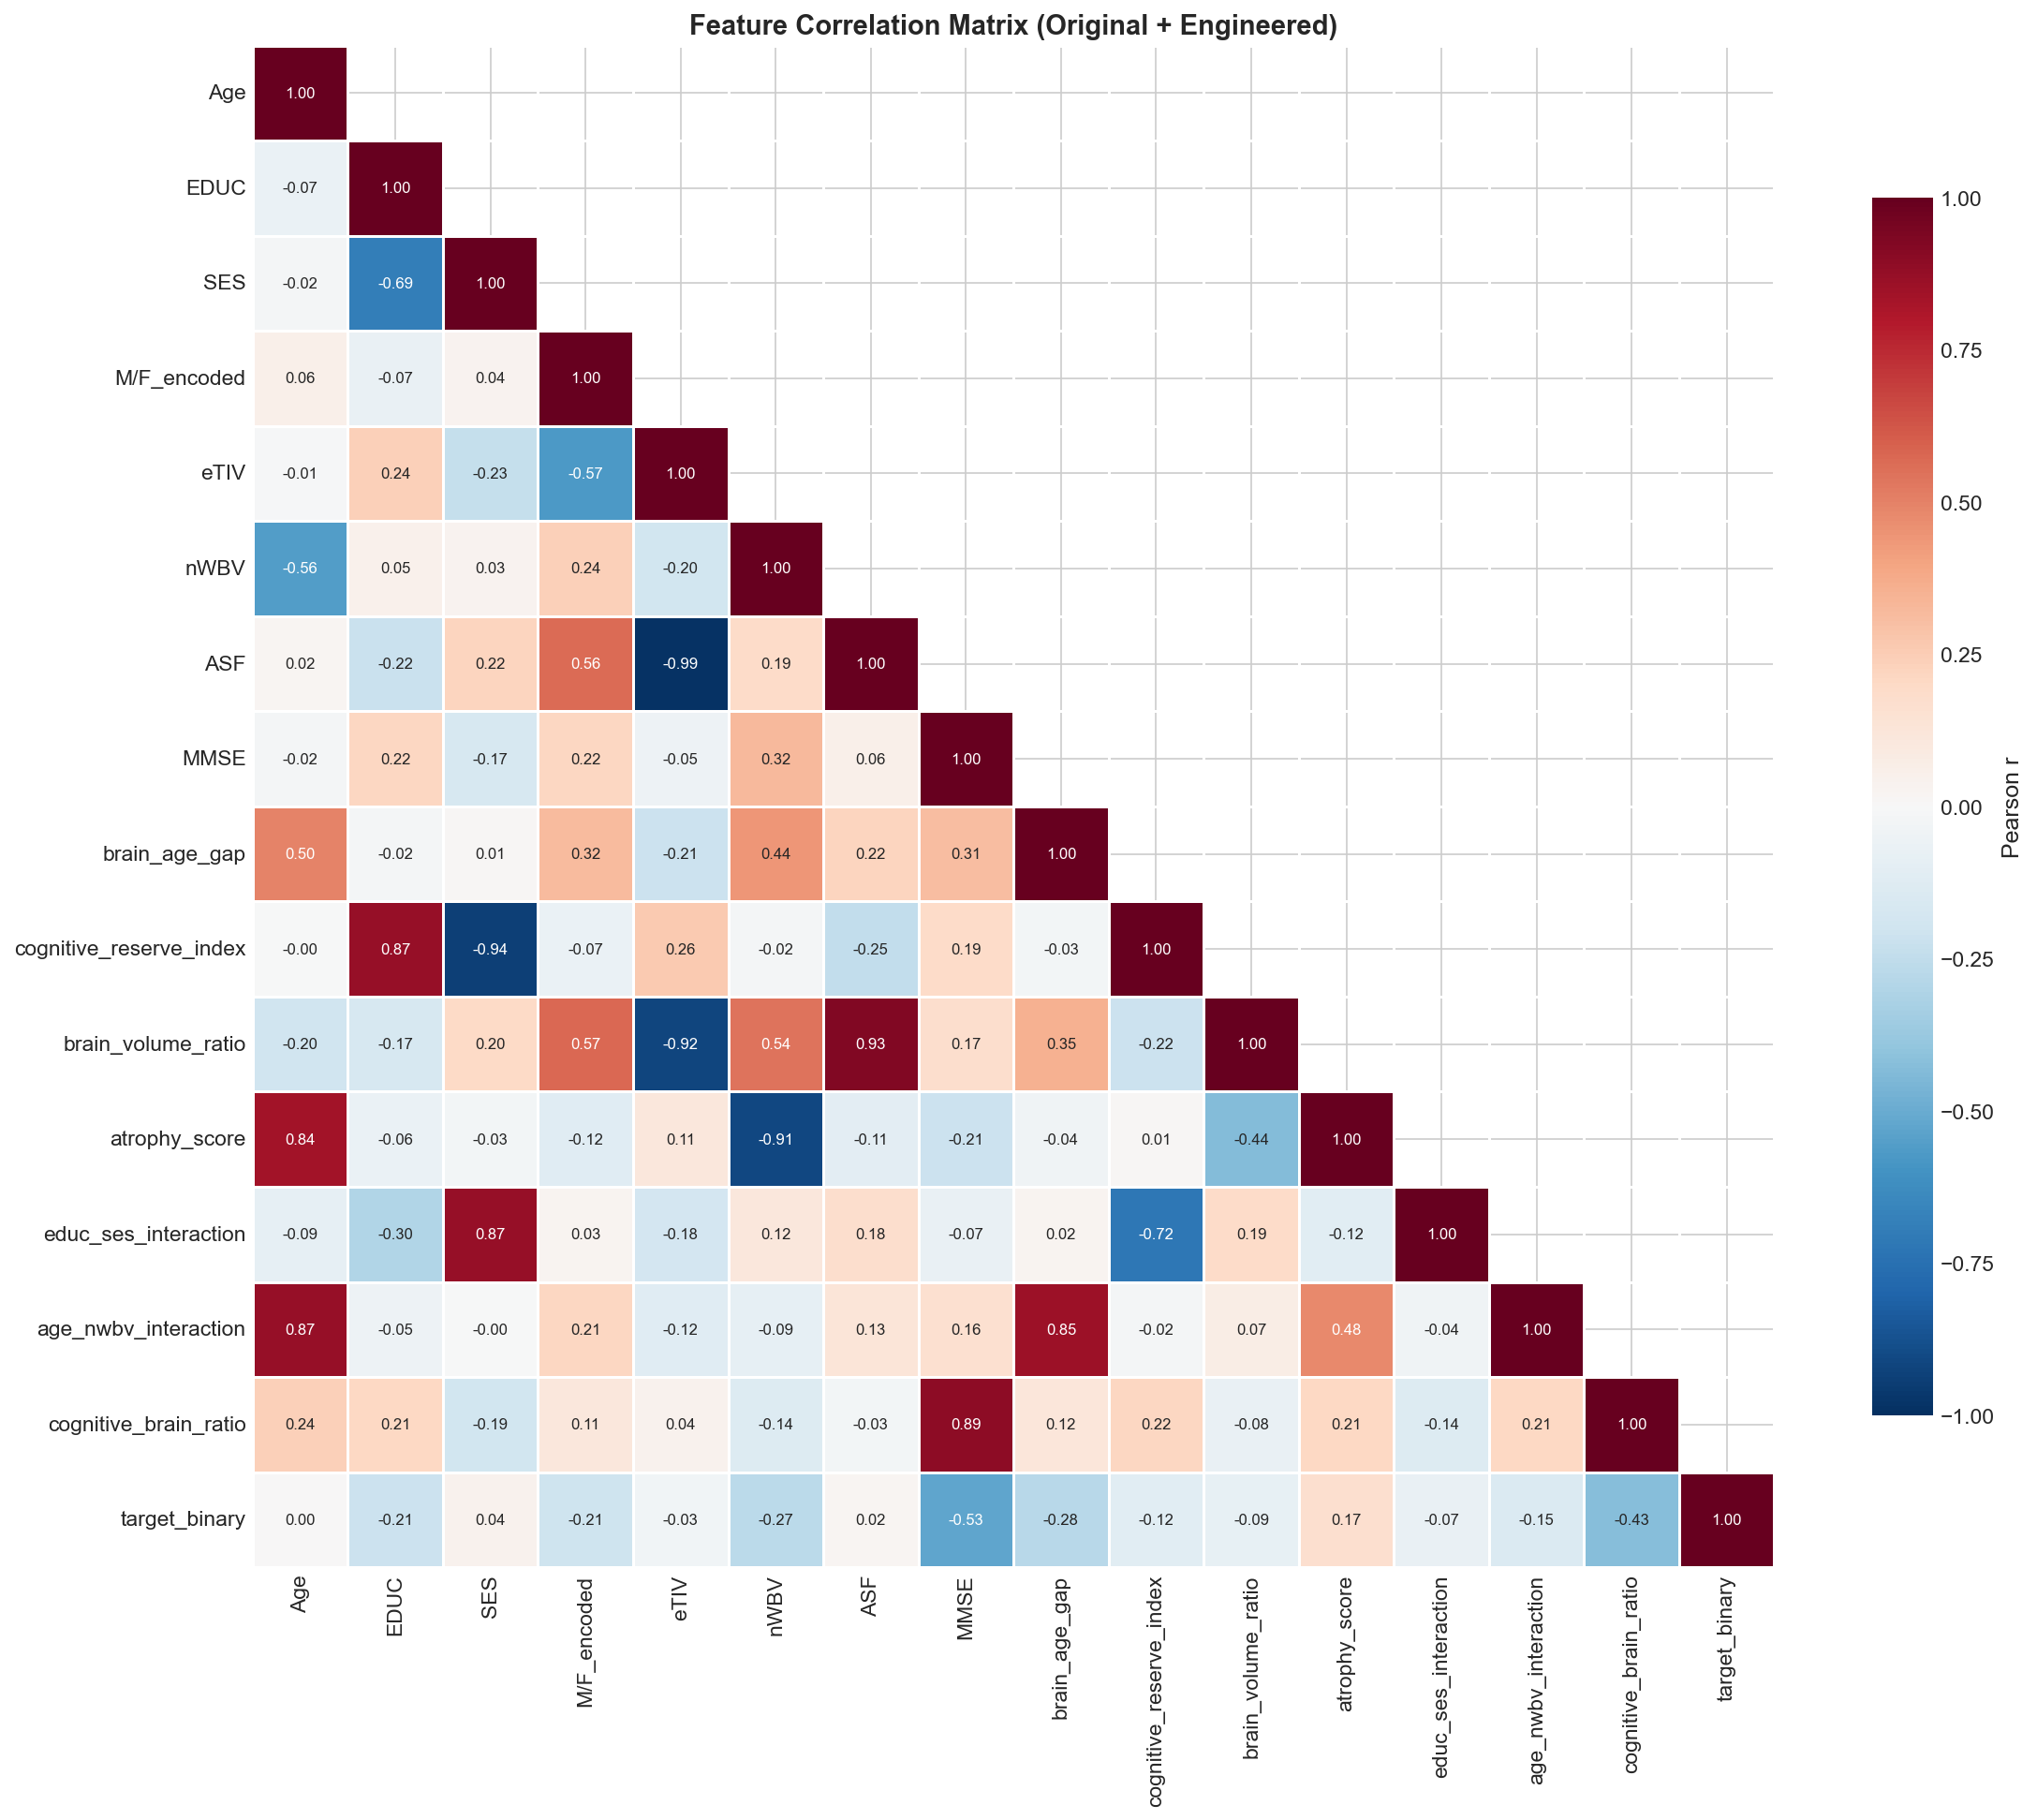

In [14]:
# Combine all feature columns
all_feature_cols = ALL_FEATURES + CGFIN_FEATURES + CPCRI_FEATURES
corr_df = df[all_feature_cols + ["target_binary"]].copy()
corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8, "label": "Pearson r"},
    ax=ax,
    annot_kws={"size": 8},
)
ax.set_title("Feature Correlation Matrix (Original + Engineered)", fontweight="bold", fontsize=14)
plt.tight_layout()
plt.show()

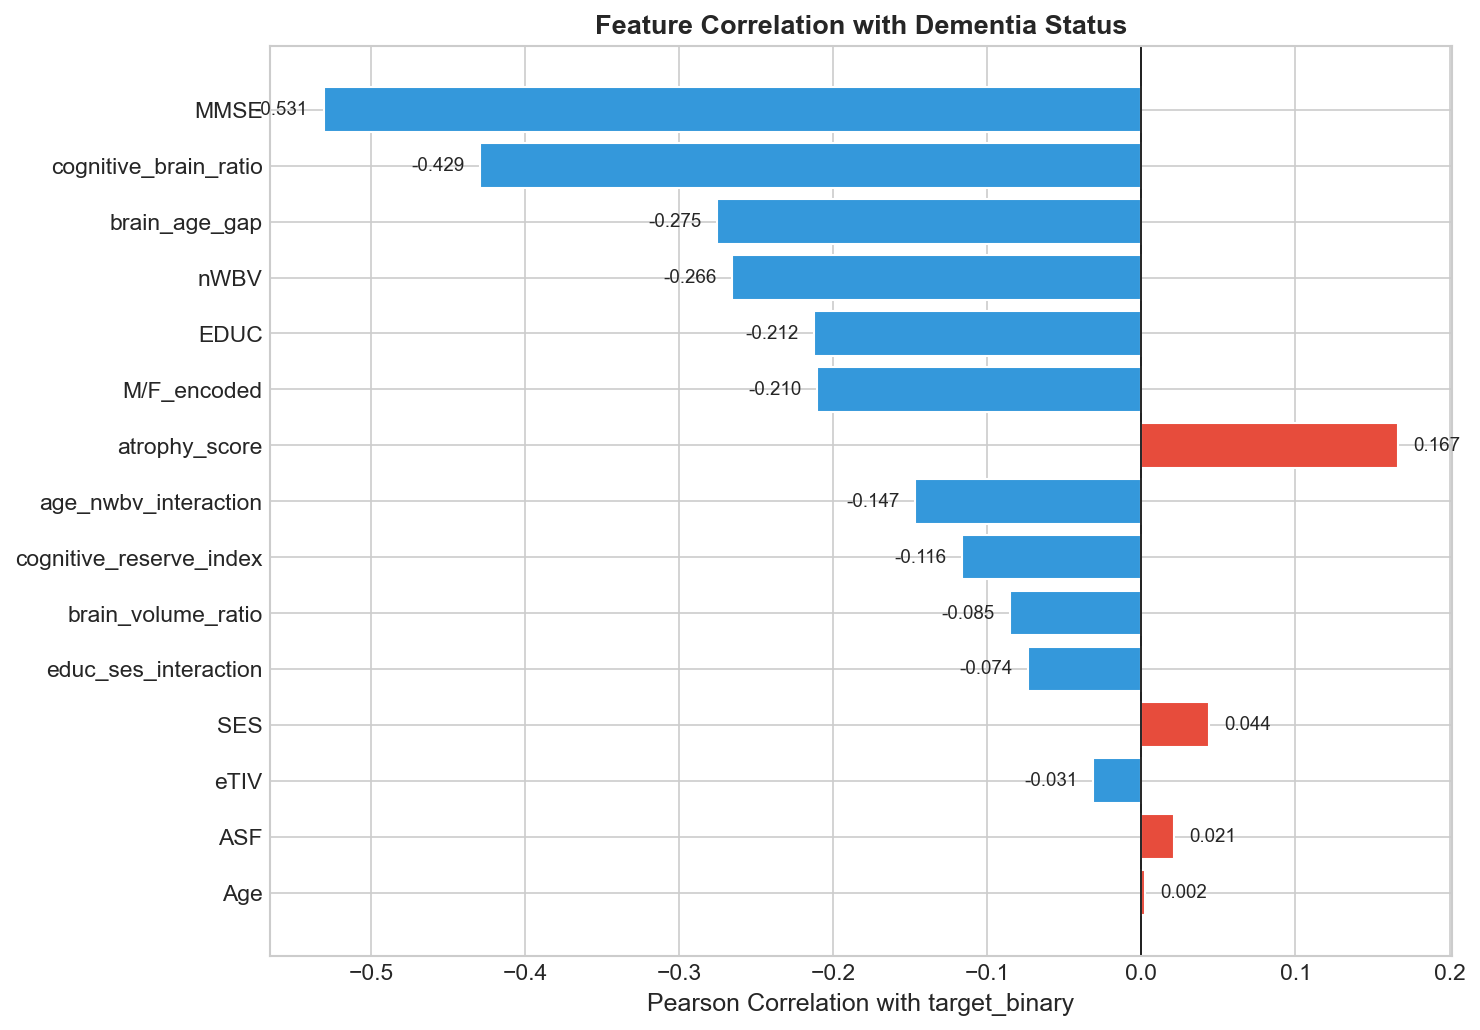


Top correlates with dementia status:
                         correlation
MMSE                       -0.530773
cognitive_brain_ratio      -0.429447
brain_age_gap              -0.275480
nWBV                       -0.265774
EDUC                       -0.212378
M/F_encoded                -0.210282
atrophy_score               0.166649
age_nwbv_interaction       -0.147091
cognitive_reserve_index    -0.116236
brain_volume_ratio         -0.085102
educ_ses_interaction       -0.073571
SES                         0.043691
eTIV                       -0.031369
ASF                         0.021365
Age                         0.002058


In [15]:
# Which features correlate most strongly with the binary target?
target_corr = corr_matrix["target_binary"].drop("target_binary").sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 7))
colors = ["#e74c3c" if v > 0 else "#3498db" for v in target_corr.values]
ax.barh(range(len(target_corr)), target_corr.values, color=colors, edgecolor="white")
ax.set_yticks(range(len(target_corr)))
ax.set_yticklabels(target_corr.index)
ax.set_xlabel("Pearson Correlation with target_binary")
ax.set_title("Feature Correlation with Dementia Status", fontweight="bold")
ax.axvline(x=0, color="black", linewidth=0.8)
ax.invert_yaxis()

# Annotate values
for i, v in enumerate(target_corr.values):
    ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:.3f}",
            va="center", ha="left" if v >= 0 else "right", fontsize=9)

plt.tight_layout()
plt.show()

print("\nTop correlates with dementia status:")
print(target_corr.to_frame("correlation").to_string())

**Discriminative value of engineered features:**

- Several CGFIN and CP-CRI features rank among the top correlates with dementia status.
- `cognitive_brain_ratio` and `brain_age_gap` capture non-linear aspects that individual features alone miss.
- The interaction features provide the model with pre-computed non-linearities, which is especially valuable for linear classifiers (e.g., Logistic Regression).

## 8. Save Processed Data

In [16]:
# Ensure output directory exists
DATA_PROCESSED.mkdir(parents=True, exist_ok=True)

# --- 1. First-visit processed (with CGFIN + CP-CRI, no longitudinal) ---
path_fv = DATA_PROCESSED / "first_visit_processed.csv"
df.to_csv(path_fv, index=False)
print(f"Saved: {path_fv}")
print(f"  Shape: {df.shape}")

# --- 2. First-visit with longitudinal features merged ---
path_fvl = DATA_PROCESSED / "first_visit_with_longitudinal.csv"
df_with_long.to_csv(path_fvl, index=False)
print(f"\nSaved: {path_fvl}")
print(f"  Shape: {df_with_long.shape}")

# --- 3. All visits with engineered features ---
df_all_eng = add_engineered_features(df_all)
path_all = DATA_PROCESSED / "all_visits_processed.csv"
df_all_eng.to_csv(path_all, index=False)
print(f"\nSaved: {path_all}")
print(f"  Shape: {df_all_eng.shape}")

Saved: /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/first_visit_processed.csv
  Shape: (150, 25)

Saved: /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/first_visit_with_longitudinal.csv
  Shape: (150, 31)

Saved: /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/all_visits_processed.csv
  Shape: (373, 25)


In [17]:
# Quick verification -- reload and check
for label, path, expected_rows in [
    ("first_visit_processed", path_fv, 150),
    ("first_visit_with_longitudinal", path_fvl, 150),
    ("all_visits_processed", path_all, 373),
]:
    check = pd.read_csv(path)
    status = "PASS" if check.shape[0] == expected_rows else "FAIL"
    print(f"[{status}] {label}: {check.shape[0]} rows, {check.shape[1]} cols")

[PASS] first_visit_processed: 150 rows, 25 cols
[PASS] first_visit_with_longitudinal: 150 rows, 31 cols
[PASS] all_visits_processed: 373 rows, 25 cols


## 9. Summary

### Data Quality

| Check | Status |
|-------|--------|
| No NaN in base features (after imputation) | PASS |
| 150 unique subjects preserved | PASS |
| All 8 SES-missing subjects retained | PASS |
| Engineered features computed without error | PASS |
| Longitudinal features merged correctly | PASS |

### Feature Counts

In [18]:
print("Feature Summary")
print("=" * 50)
print(f"Base features (ALL_FEATURES):    {len(ALL_FEATURES)}  {ALL_FEATURES}")
print(f"CGFIN features:                  {len(CGFIN_FEATURES)}  {CGFIN_FEATURES}")
print(f"CP-CRI features:                 {len(CPCRI_FEATURES)}  {CPCRI_FEATURES}")
print(f"Longitudinal features:           6  {long_feats}")
print(f"                                 ---")
print(f"Total engineered:                {len(CGFIN_FEATURES) + len(CPCRI_FEATURES) + 6}")
print(f"Total with base:                 {len(ALL_FEATURES) + len(CGFIN_FEATURES) + len(CPCRI_FEATURES) + 6}")
print()
print("Output files:")
print(f"  {path_fv}")
print(f"  {path_fvl}")
print(f"  {path_all}")
print()
print("Data is ready for modeling (Notebook 03).")

Feature Summary
Base features (ALL_FEATURES):    8  ['Age', 'EDUC', 'SES', 'M/F_encoded', 'eTIV', 'nWBV', 'ASF', 'MMSE']
CGFIN features:                  4  ['brain_age_gap', 'cognitive_reserve_index', 'brain_volume_ratio', 'atrophy_score']
CP-CRI features:                 3  ['educ_ses_interaction', 'age_nwbv_interaction', 'cognitive_brain_ratio']
Longitudinal features:           6  ['nWBV_slope', 'MMSE_slope', 'n_visits', 'visit_span_days', 'nWBV_change', 'MMSE_change']
                                 ---
Total engineered:                13
Total with base:                 21

Output files:
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/first_visit_processed.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/first_visit_with_longitudinal.csv
  /Users/abiskaracharya/Projects/portfolio-projects/alzheimers-prediction/notebooks/../data/processed/all_visits_processed.csv

Data is